In [1]:
import pandas as pd
data=pd.read_csv(r"C:\Users\musha\OneDrive\سطح المكتب\Reem mu\UNSW_NB15_training-set.csv")
data

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.090200,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.000300,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.005100,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.660800,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.002500,...,1,3,0,0,0,2,3,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82327,82328,0.000005,udp,-,INT,2,0,104,0,200000.005100,...,1,2,0,0,0,2,1,0,Normal,0
82328,82329,1.106101,tcp,-,FIN,20,8,18062,354,24.410067,...,1,1,0,0,0,3,2,0,Normal,0
82329,82330,0.000000,arp,-,INT,1,0,46,0,0.000000,...,1,1,0,0,0,1,1,1,Normal,0
82330,82331,0.000000,arp,-,INT,1,0,46,0,0.000000,...,1,1,0,0,0,1,1,1,Normal,0


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [9]:
#استخدام عينة 10% من أجل الذاكرة
data_sample = data.sample(frac=0.1, random_state=42)

In [10]:
#التحضير من عينة البيانات
X = data_sample.drop(columns=['id', 'label', 'attack_cat'])
y = data_sample['label']

In [11]:
#التحويل من فئات إلى رقمية
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
#تهيئة وتدريب Decision Tree
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [14]:
#Predict
y_pred = tree_model.predict(X_test)

In [15]:
#النتائج
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [16]:
accuracy, report

(0.9275303643724696,
 '              precision    recall  f1-score   support\n\n           0       0.92      0.92      0.92      1137\n           1       0.93      0.93      0.93      1333\n\n    accuracy                           0.93      2470\n   macro avg       0.93      0.93      0.93      2470\nweighted avg       0.93      0.93      0.93      2470\n')

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, recall_score, precision_score

# نموذج DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=5, random_state=42)

# تدريب النموذج
model.fit(X_train, y_train)

# التنبؤ بالنتائج
y_pred = model.predict(X_test)

# حساب المقاييس
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')

# عرض النتائج
print(f'F1 Score: {f1}')
print(f'Recall: {recall}')
print(f'Precision: {precision}')

F1 Score: 0.9275232265671132
Recall: 0.9275303643724696
Precision: 0.9275188409249233


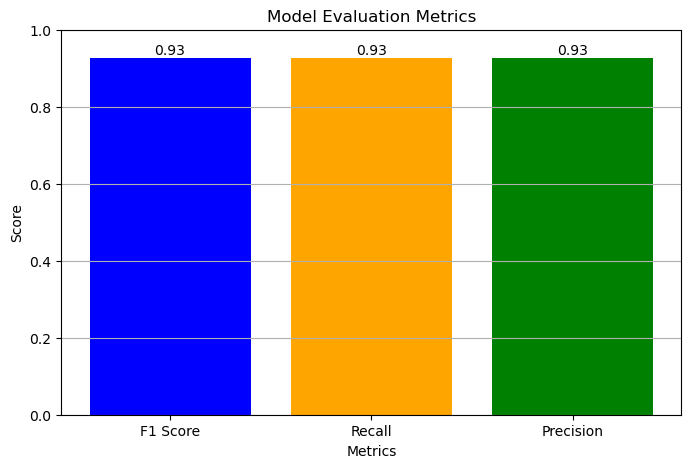

In [19]:
import matplotlib.pyplot as plt

# Evaluation metrics
metrics = ['F1 Score', 'Recall', 'Precision']
scores = [f1, recall, precision]

# Create a bar graph
plt.figure(figsize=(8, 5))
plt.bar(metrics, scores, color=['blue', 'orange', 'green'])
plt.ylim(0, 1)  # Set y-axis limits to [0, 1]
plt.title('Model Evaluation Metrics')
plt.ylabel('Score')
plt.xlabel('Metrics')

# Display the score values on top of the bars
for index, value in enumerate(scores):
    plt.text(index, value, f'{value:.2f}', ha='center', va='bottom')

plt.grid(axis='y')
plt.show()